### Here we are importing the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene



In [2]:
df= pd.read_csv(r"/home/amr/Repos/myLaTeX/mvsReport/housing.csv")


### Here we are exploring the data

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### We have 20640 records! 

In [5]:
df.shape

(20640, 10)

### Exploring the data types of each field

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Descriptive statistics

### Mean vector, STD vector, quantiles, min & max

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Checking to see if there are any null values

In [8]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Filling the null values with the median

In [10]:
df = df.fillna(df['total_bedrooms'].median())

### Checking for duplicates

In [11]:
df.duplicated().sum()

0

In [12]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### Testing for normality

In [18]:
from scipy.stats import shapiro
from scipy import stats
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    data = df[col]
    stat, p_value = stats.shapiro(data)
    print(f"\nColumn: {col}")
    print(f"Shapiro Statistic: {stat:.4f}, P-value: {p_value:.4e}")
    if p_value > 0.05:
        print("Normal")
    else:
        print("Not normal")


Column: longitude
Shapiro Statistic: 0.8970, P-value: 4.1213e-78
Not normal

Column: latitude
Shapiro Statistic: 0.8771, P-value: 4.4952e-82
Not normal

Column: housing_median_age
Shapiro Statistic: 0.9782, P-value: 1.5602e-47
Not normal

Column: total_rooms
Shapiro Statistic: 0.6952, P-value: 4.7783e-104
Not normal

Column: total_bedrooms
Shapiro Statistic: nan, P-value: nan
Not normal

Column: population
Shapiro Statistic: 0.7133, P-value: 1.7445e-102
Not normal

Column: households
Shapiro Statistic: 0.7456, P-value: 1.8379e-99
Not normal

Column: median_income
Shapiro Statistic: 0.8932, P-value: 6.5600e-79
Not normal

Column: median_house_value
Shapiro Statistic: 0.9123, P-value: 1.3673e-74
Not normal


### Test of equal variances 

In [19]:
group1 = df[df['ocean_proximity'] == 'INLAND']['median_house_value']
group2 = df[df['ocean_proximity'] == 'NEAR BAY']['median_house_value']

stat, p_value = levene(group1, group2)
print("\nLevene Test (Equal Variance):")
print(f"Statistic: {stat:.4f}, P-value: {p_value:.4e}")
if p_value > 0.05:
    print("✅ Variances are equal")
else:
    print("❌ Variances are NOT equal")


Levene Test (Equal Variance):
Statistic: 1318.1708, P-value: 3.7005e-269
❌ Variances are NOT equal


### Mean vector

In [15]:
df.mean(numeric_only=True)

longitude               -119.569704
latitude                  35.631861
housing_median_age        28.639486
total_rooms             2635.763081
total_bedrooms           536.838857
population              1425.476744
households               499.539680
median_income              3.870671
median_house_value    206855.816909
dtype: float64

### Covariance Matrix

In [16]:
df.cov(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,4.014139,-3.957054,-2.728244,1.948037e+02,5.807886e+01,2.263778e+02,4.236807e+01,-0.057765,-1.062743e+04
latitude,-3.957054,4.562293,0.300346,-1.682178e+02,-5.955635e+01,-2.631378e+02,-5.801024e+01,-0.323860,-3.553256e+04
housing_median_age,-2.728244,0.300346,158.396260,-9.919120e+03,-1.683911e+03,-4.222271e+03,-1.457581e+03,-2.846140,1.533988e+05
total_rooms,194.803750,-168.217847,-9919.120060,4.759445e+06,8.482135e+05,2.117613e+06,7.661046e+05,820.852410,3.377289e+07
total_bedrooms,58.078858,-59.556355,-1683.910513,8.482135e+05,1.758895e+05,4.148814e+05,1.562357e+05,-6.068896,2.393514e+06
population,226.377839,-263.137814,-4222.270582,2.117613e+06,4.148814e+05,1.282470e+06,3.928036e+05,10.400979,-3.221249e+06
households,42.368072,-58.010245,-1457.581290,7.661046e+05,1.562357e+05,3.928036e+05,1.461760e+05,9.466667,2.904924e+06
median_income,-0.057765,-0.323860,-2.846140,8.208524e+02,-6.068896e+00,1.040098e+01,9.466667e+00,3.609323,1.508475e+05
median_house_value,-10627.425205,-35532.559074,153398.801329,3.377289e+07,2.393514e+06,-3.221249e+06,2.904924e+06,150847.482793,1.331615e+10


## Heat Map Graph

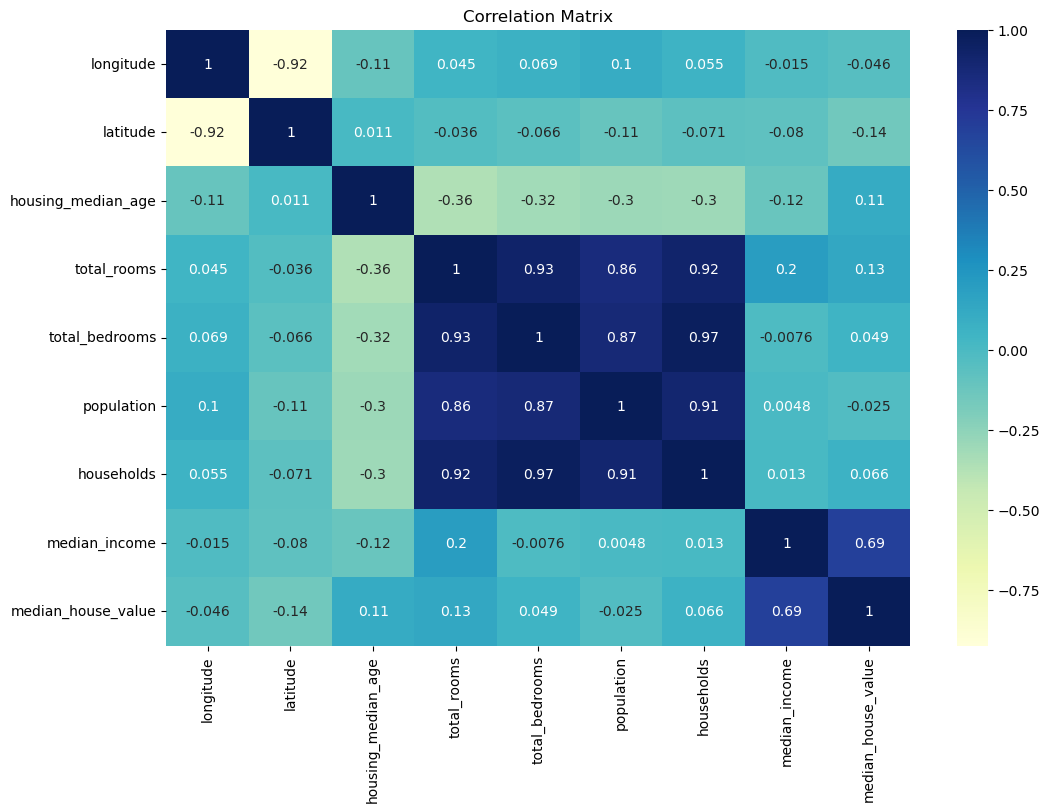

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")  
plt.title("Correlation Matrix")
plt.show()

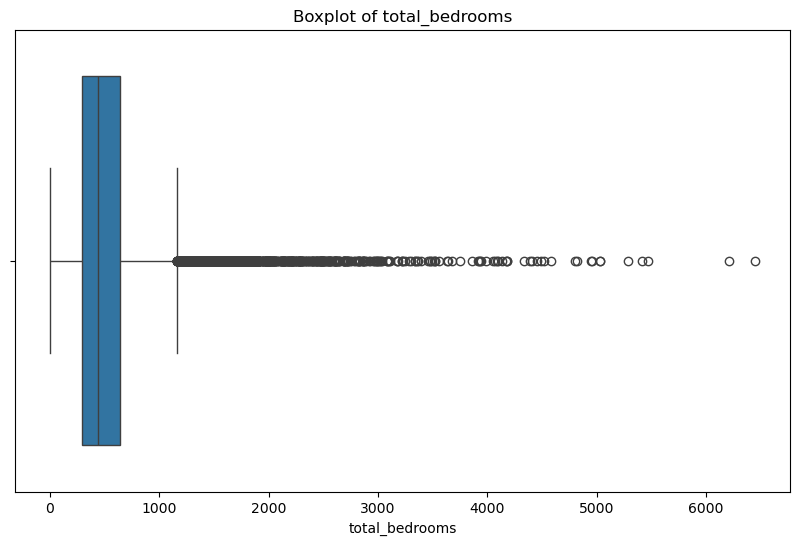

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['total_bedrooms'])
plt.title('Boxplot of total_bedrooms')
plt.savefig('total_bedrooms.png')
plt.show()

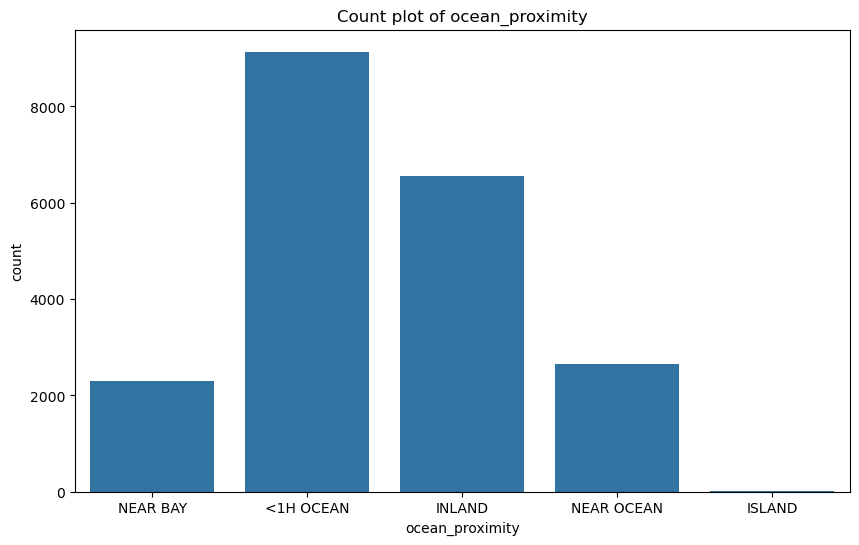

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='ocean_proximity', data=df)
plt.title('Count plot of ocean_proximity')
plt.savefig('ocean_proximity.png')
plt.show()
